In [1]:
# matrikelnummer 00000

import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import math


def plot_samples(data,
                 n=5,
                 max_cols=5,
                 cmap="tab20"
                 ):
    n = min(len(data), n)
    if n < max_cols:
        rows = 1
        cols = n
    else:
        rows = math.ceil(n / max_cols)
        cols = max_cols
    print(f"rows: {rows}, cols: {cols}")
    fig, ax = plt.subplots(nrows=rows, ncols=cols, sharex=True, sharey=True, figsize=(20, 10))
    #ax = ax.flatten()
    index = 0
    for i in range(rows):
        for j in range(cols):
            img = data[index]
            index += 1
            #    .numpy().reshape(X.shape[1],X.shape[2],2)
            print()
            ax[i, j].imshow(img, cmap=cmap, interpolation='nearest')
            if index >= n:
                break

    #ax[0].set_xticks([])
    #ax[0].set_yticks([])
    plt.tight_layout()
    # plt.savefig('./figures/mnist_all.png', dpi=300)
    plt.show()

### Datensätze laden und vorbereiten

In [2]:
(mnist_images, mnist_labels), (mnist_images_test, mnist_labels_test) = keras.datasets.mnist.load_data()
print(mnist_images.shape)
print(mnist_images_test.shape)

(60000, 28, 28)
(10000, 28, 28)


2026-06-02 19:14:59.787882: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-06-02 19:14:59.787910: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2026-06-02 19:14:59.787917: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 25.92 GB
I0000 00:00:1780420499.787928 85537337 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780420499.787944 85537337 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


rows: 4, cols: 5






















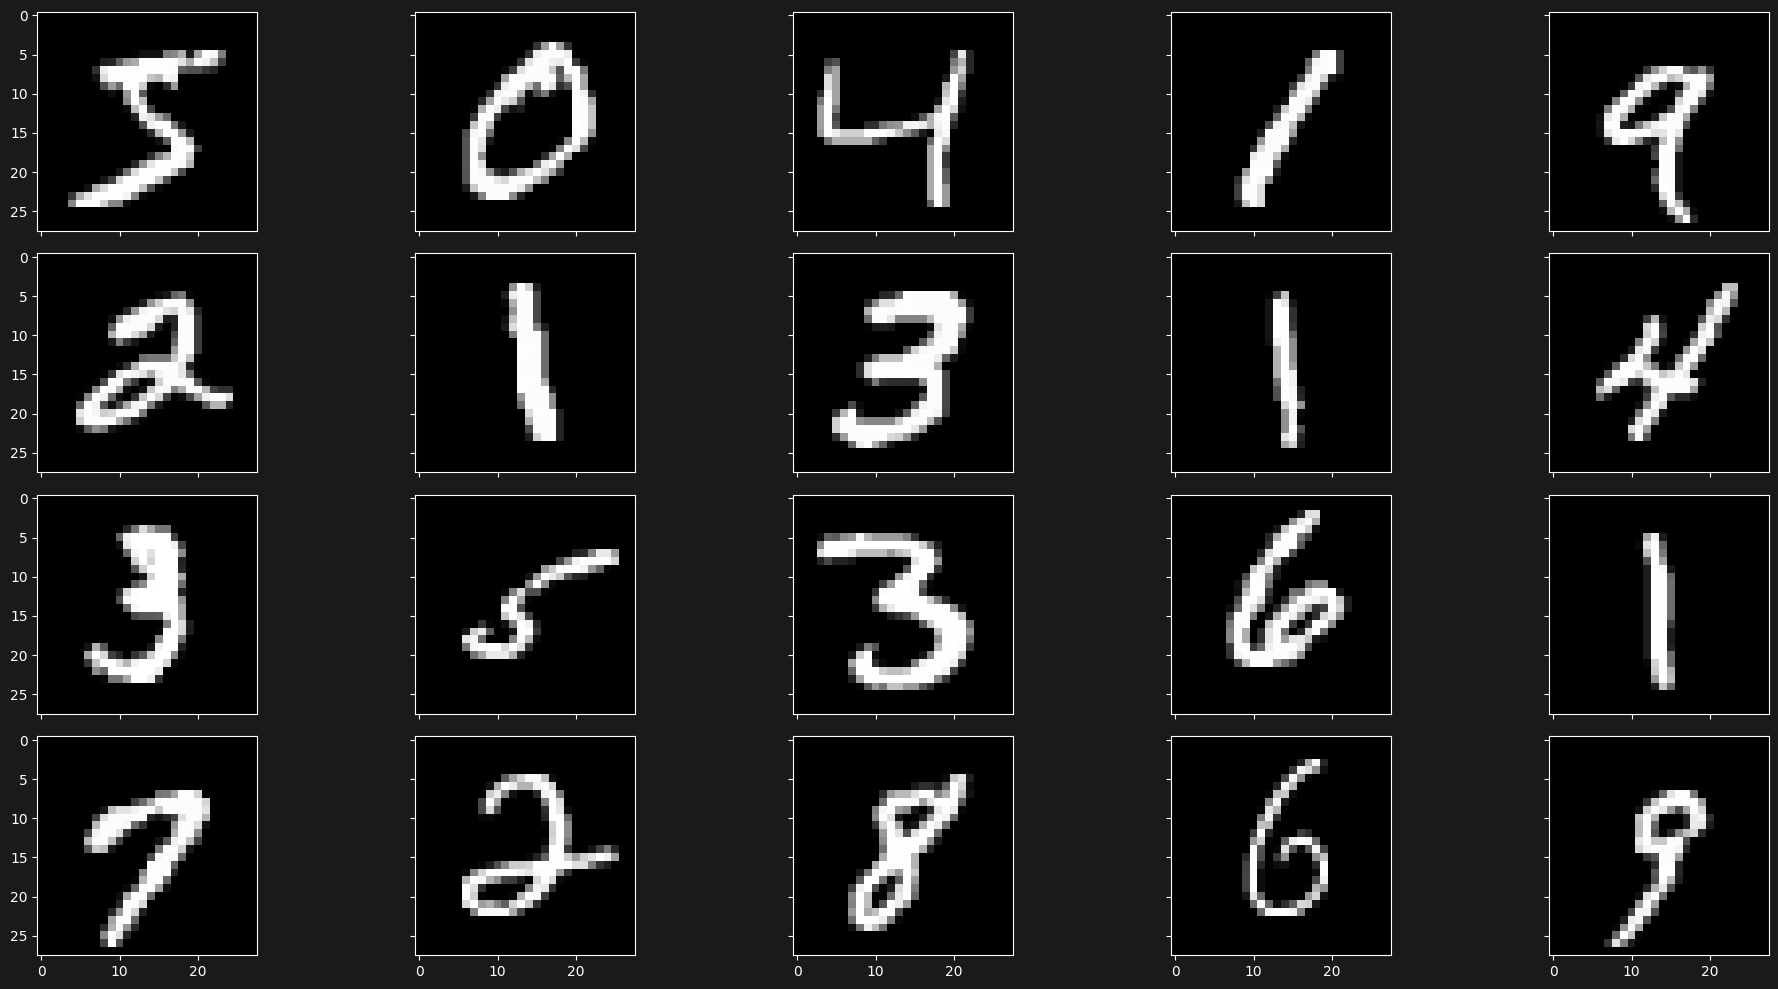

tf.Tensor([5 0 4 1 9 2 1 3 1 4 3 5 3 6 1 7 2 8 6 9], shape=(20,), dtype=int64)


In [3]:
X_train_digits = tf.cast(mnist_images / 255, tf.float32)
y_train_digits = tf.cast(mnist_labels, tf.int64)
X_test_digits = tf.cast(mnist_images_test / 255, tf.float32)
y_test_digits = tf.cast(mnist_labels_test, tf.int64)
plot_samples(X_train_digits, n=20, cmap="gray")
print(y_train_digits[:20])

rows: 4, cols: 5






















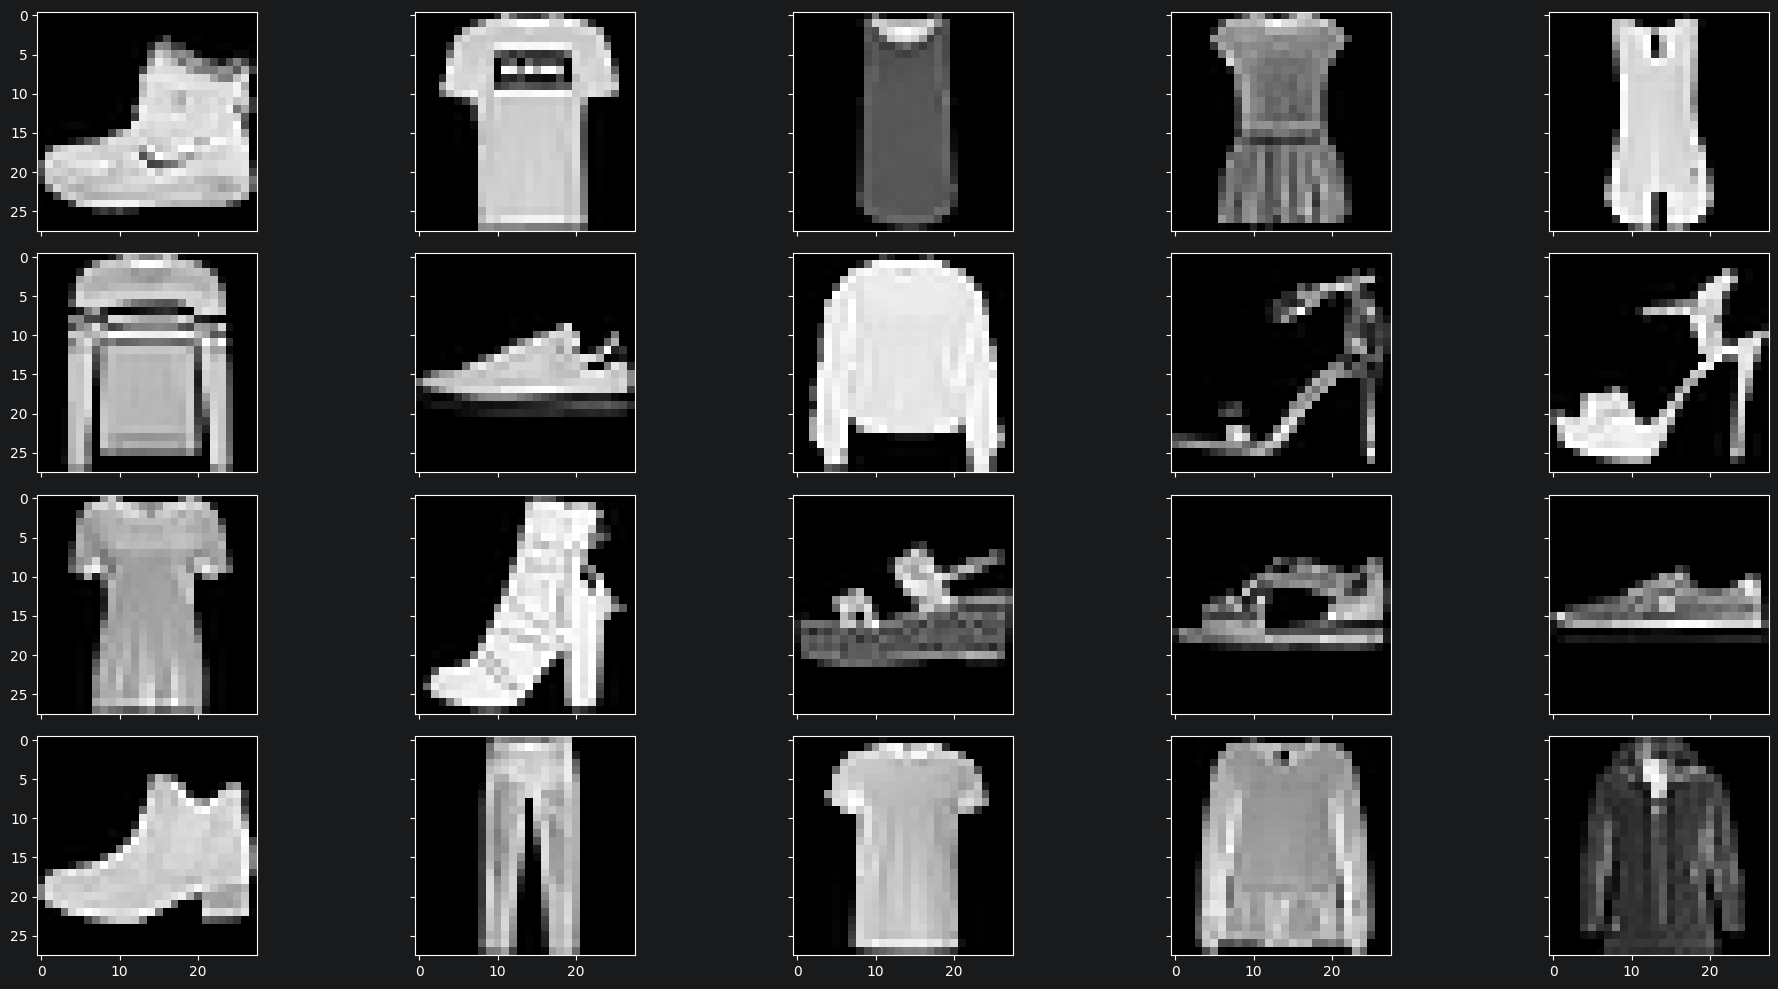

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4]


In [4]:
nr_negative_examples = 10_000
fashion_mnist = keras.datasets.fashion_mnist.load_data()
(Xf_train_full, yf_train_full), (Xf_test, yf_test) = fashion_mnist
X_train_negative = Xf_train_full[:nr_negative_examples]
X_test_negative = Xf_test
X_train_negative = tf.cast(X_train_negative / 255, tf.float32)
X_test_negative = tf.cast(X_test_negative / 255, tf.float32)
plot_samples(X_train_negative, n=20, cmap="grey")
print(yf_train_full[:20])

In [5]:
y_train_negative = tf.constant(10, shape=(nr_negative_examples,), dtype=tf.int64)
y_test_negative = tf.constant(10, shape=(len(X_test_negative),), dtype=tf.int64)
print(y_train_negative.shape)

(10000,)


In [6]:
X_train = tf.concat([X_train_digits, X_train_negative], axis=0)
y_train = tf.concat([y_train_digits, y_train_negative], axis=0)
print(X_train.shape)
print(y_train.shape)

(70000, 28, 28)
(70000,)


In [7]:
X_test = tf.concat([X_test_digits, X_test_negative], axis=0)
y_test = tf.concat([y_test_digits, y_test_negative], axis=0)
print(X_test.shape)
print(y_test.shape)

(20000, 28, 28)
(20000,)


### Modell erstellen, trainieren und evaluieren

In [8]:
model = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                # keras.layers.Dense(128, activation="relu"),
                keras.layers.Dense(128, activation="selu"),
                keras.layers.Dense(64, activation="relu"),
                keras.layers.Dense(11, activation="softmax")
                ]
        )
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,451 (427.54 KB)

 Trainable params: 109,451 (427.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.01,
        restore_best_weights=True
        )
model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=64,
        validation_data=(X_test, y_test),
        verbose=1,
        callbacks=[early_stopping]
        )

Epoch 1/20


2026-06-02 19:17:07.826700: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9104 - loss: 0.3094 - val_accuracy: 0.9651 - val_loss: 0.1225
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9330 - loss: 0.2481 - val_accuracy: 0.9577 - val_loss: 0.1606
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.9297 - loss: 0.3117 - val_accuracy: 0.9560 - val_loss: 0.2072


In [13]:
early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="accuracy",
        patience=2,
        min_delta=0.02,
        restore_best_weights=True
        )
model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=64,
        verbose=1,
        callbacks=[early_stopping]
        )

Epoch 1/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9213 - loss: 0.2896
Epoch 2/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9109 - loss: 0.3289
Epoch 3/20
1016/1016 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8424 - loss: 1.0319


In [10]:
model.evaluate(X_test_negative, y_test_negative)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9973 - loss: 0.0095


[0.00951413530856371, 0.9973000288009644]

In [11]:
model.evaluate(X_test_digits, y_test_digits)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9329 - loss: 0.2355


[0.23552066087722778, 0.9329000115394592]

In [14]:
def predict(model, images, threshold=0.5):
    images = tf.convert_to_tensor(images)
    single_image = images.shape.rank == 2
    if single_image:
        images = tf.reshape(images, (1, 28, 28))

    y_pred = model(images)
    y_proba = tf.reduce_max(y_pred, axis=1)
    y_class = tf.argmax(y_pred, axis=1)
    result = [None if float(proba) < threshold else int(cls) for cls, proba in zip(y_class, y_proba)]
    return result[0] if single_image else result
    # y_pred = tf.squeeze(y_pred)


result = predict(model, X_test_digits[:10, :, :])
print(y_test_digits[:10])
print(f"Predicted class: {result}")

tf.Tensor([7 2 1 0 4 1 4 9 5 9], shape=(10,), dtype=int64)
Predicted class: [2, 2, None, 6, 4, 9, 4, 9, 6, 9]


tf.Tensor([7 2 1 0 4 1 4 9 5 9], shape=(10,), dtype=int64)
Predicted class: [2, 2, None, 6, 4, 9, 4, 9, 6, 9]
rows: 2, cols: 5












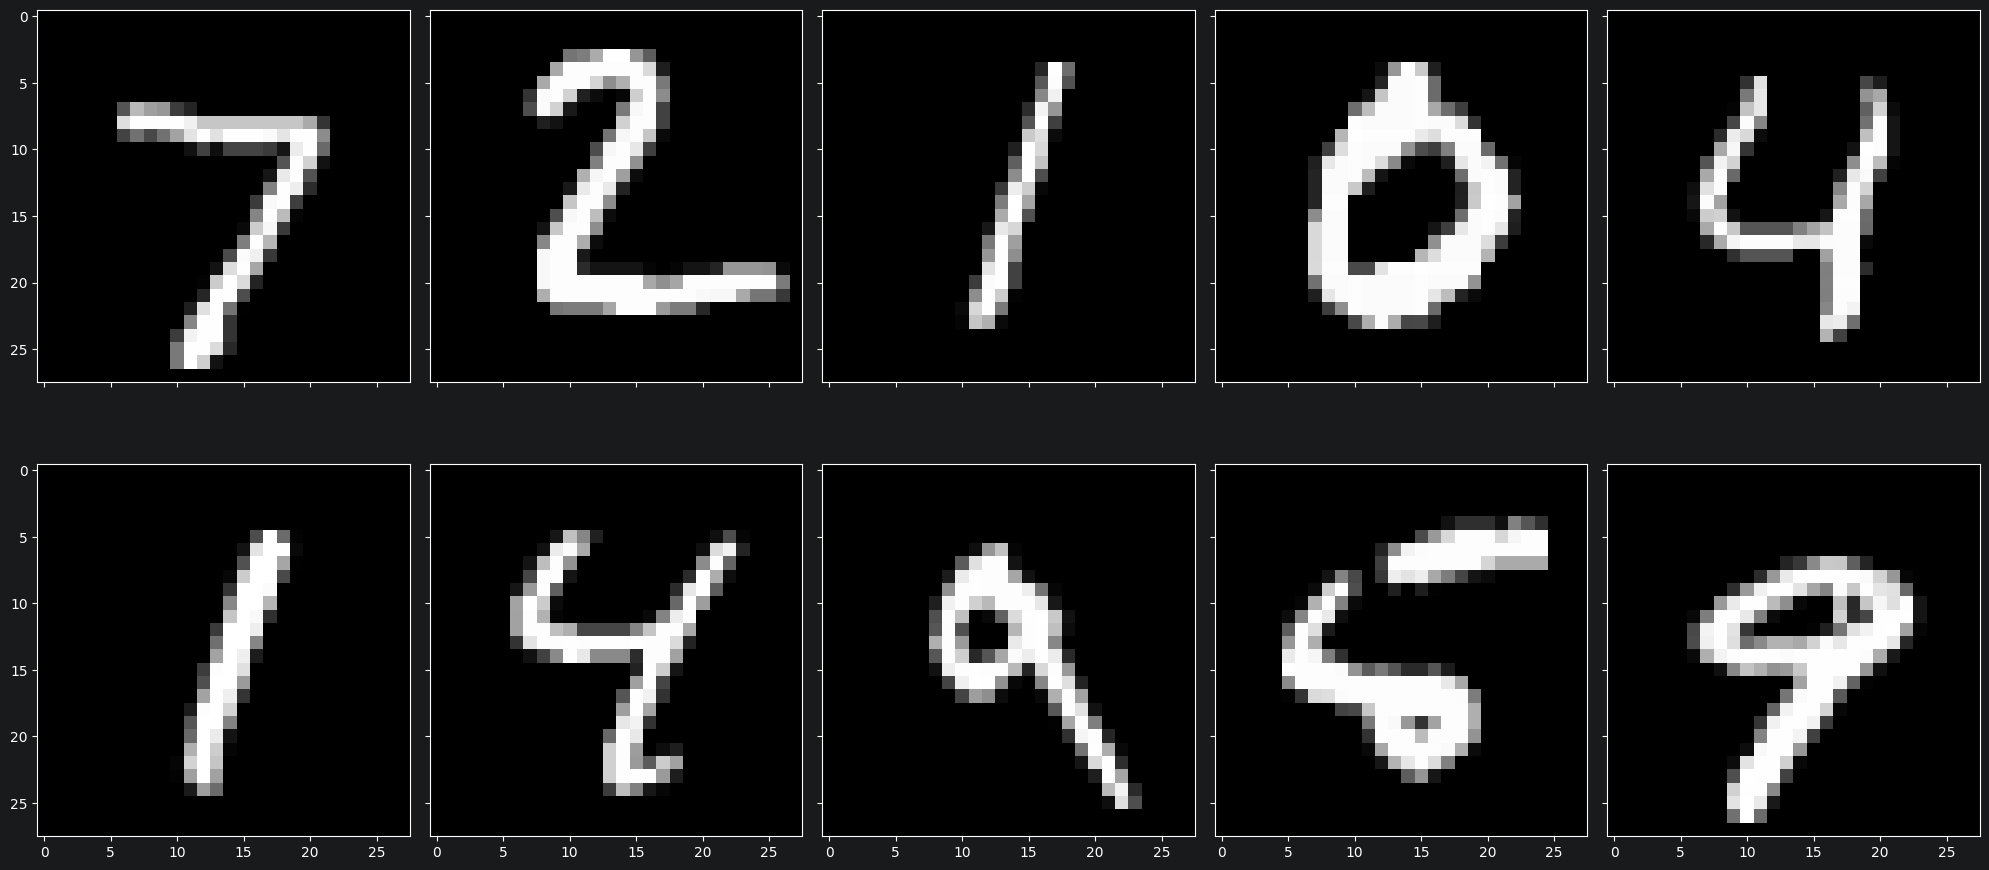

In [15]:
digits = X_test_digits[:10]
print(y_test_digits[:10])
result = predict(model, digits)
print(f"Predicted class: {result}")
plot_samples(digits, n=10, cmap="gray")

### Dataset

In [16]:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
for x, y in dataset.take(5):
    print(f"x: {x.shape}, y: {y}")
train_dataset = dataset.shuffle(buffer_size=len(X_train), reshuffle_each_iteration=True).batch(64).prefetch(
        buffer_size=tf.data.AUTOTUNE
        )

x: (28, 28), y: 5
x: (28, 28), y: 0
x: (28, 28), y: 4
x: (28, 28), y: 1
x: (28, 28), y: 9


2026-06-02 19:21:11.081348: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [41]:
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(buffer_size=len(X_train), reshuffle_each_iteration=True).batch(64).prefetch(
        buffer_size=tf.data.AUTOTUNE
        )
for x, y in train_dataset.take(1):
    print(f"x: {x.shape}, y: {y}")

x: (64, 28, 28), y: [ 1  3  1  7  5 10  9  1  0  0  7  4  8  9  9  2  4 10  2  9  6  2  8  3
  1  6  4  9  3  3  6  2  3  7  5  2  2  7  2 10 10 10  2  4 10  7  1  8
  1  1  1  8  4  4  9  1  3  7 10  3  1  5 10  7]


In [26]:
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)

In [28]:
model2 = keras.models.Sequential(
        [
                keras.layers.Input(shape=[28, 28]),
                keras.layers.Flatten(),
                keras.layers.Dense(64, activation="selu"),
                keras.layers.Dense(20, activation="selu"),
                keras.layers.Dense(11, activation="softmax")
                ]
        )
model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 20)             │         1,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 11)             │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,771 (202.23 KB)

 Trainable params: 51,771 (202.23 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stopping_val_loss = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        min_delta=0.005,
        restore_best_weights=True
        )
model2.fit(
        X_train,
        y_train,
        batch_size=64,
        epochs=100,
        verbose=1,
        # validation_split=0.1,
        validation_data=test_dataset,
        callbacks=[early_stopping_val_loss]
        )


Epoch 1/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - accuracy: 0.9101 - loss: 0.3158 - val_accuracy: 0.9671 - val_loss: 0.1115
Epoch 2/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9521 - loss: 0.1633 - val_accuracy: 0.9750 - val_loss: 0.0847
Epoch 3/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9644 - loss: 0.1190 - val_accuracy: 0.9792 - val_loss: 0.0690
Epoch 4/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9713 - loss: 0.0945 - val_accuracy: 0.9815 - val_loss: 0.0606
Epoch 5/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9765 - loss: 0.0769 - val_accuracy: 0.9821 - val_loss: 0.0561
Epoch 6/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9833 - val_loss: 0.0548
Epoch 7/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9833 - loss: 0.0549 - val_accuracy: 0.9855 - val_loss: 0.0483
Epoch 8/100
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 

In [30]:
model.evaluate(X_test, y_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9651 - loss: 0.1225


[0.12251731008291245, 0.9650999903678894]

tf.Tensor([7 2 1 0 4 1 4 9 5 9], shape=(10,), dtype=int64)
Predicted class: [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
rows: 2, cols: 5












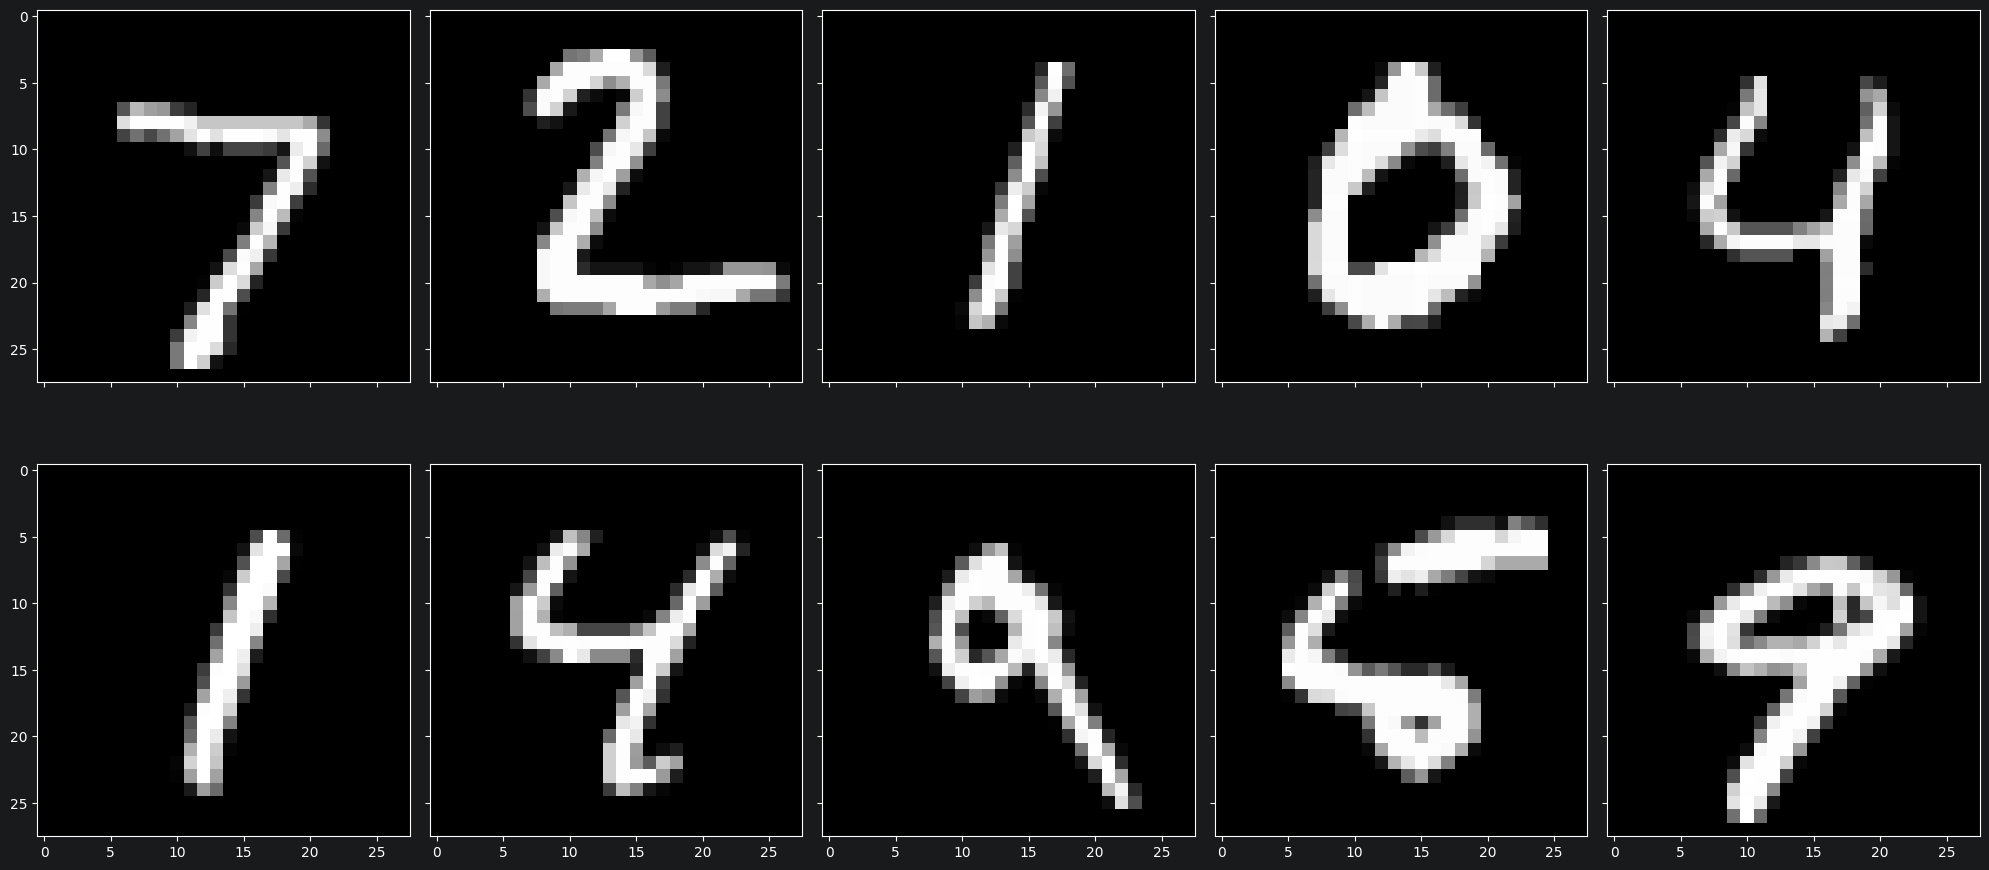

In [31]:
digits = X_test_digits[:10]
print(y_test_digits[:10])
result = predict(model2, digits)
print(f"Predicted class: {result}")
plot_samples(digits, n=10, cmap="gray")

tf.Tensor([10 10 10 10 10 10 10 10 10 10], shape=(10,), dtype=int64)
Predicted class: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
rows: 2, cols: 5












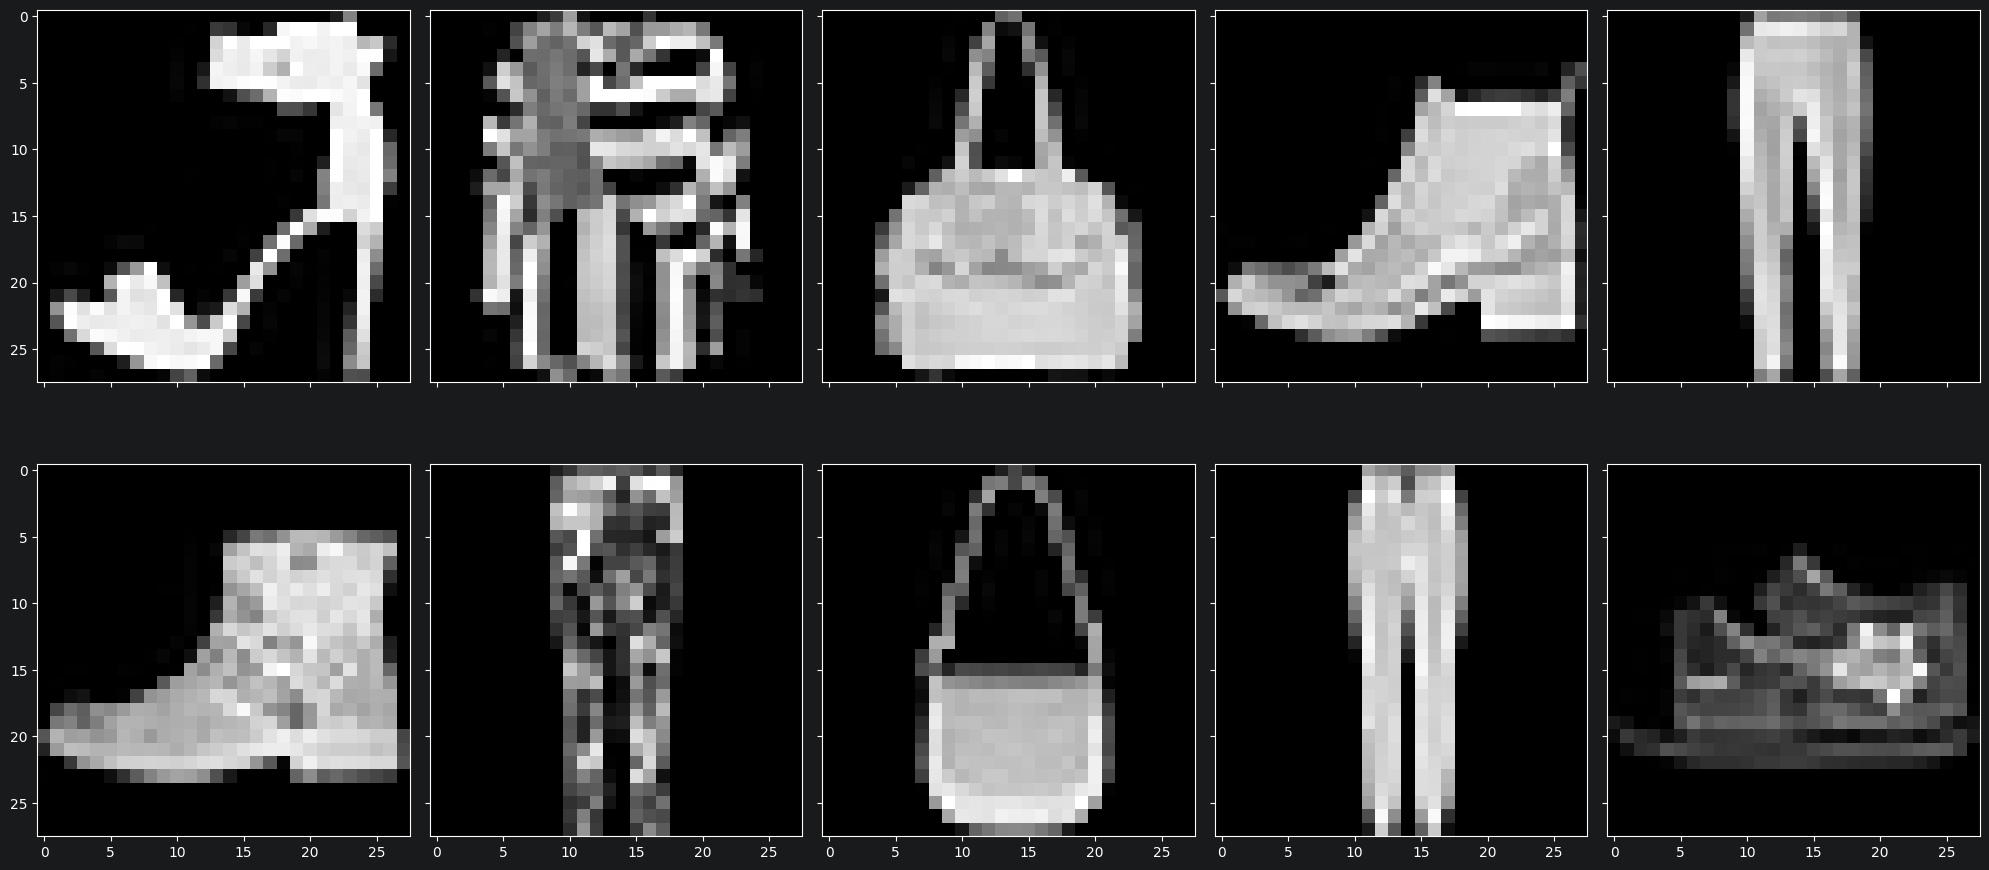

In [34]:
negatives = X_test[-10:]
print(y_test[-10:])
result = predict(model2, negatives)
print(f"Predicted class: {result}")
plot_samples(negatives, n=10, cmap="gray")